## Сегментация клиентов индийского банка

### 1. Импорт необходимых библиотек и датасета

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import re

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture

#import geopandas as gpd

#pd.options.mode.copy_on_write = True

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/bank_transactions.csv')
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


Описание признаков датасета:
* TransactionID - ид транзакции
* CustomerID - ид клиента
* CustomerDOB - день рождения клиента
* CustGender - пол клиента
* CustLocation - город выполнения транзакции
* CustAccountBalance - остаток на счете
* TransactionDate - дата транзакции
* TransactionTime - время транзакции (unix timestamp)
* TransactionAmount (INR) - сумма транзакции

### 2. Чистка данных

In [ ]:
print(f"Размер данных: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропущенные значения:\n{df.isnull().sum()}")
print(f"\nДубликаты 'TransactionID':\n{df.duplicated(subset=['TransactionID']).sum()}")
print(f"\nДубликаты 'CustomerID':\n{df.duplicated(subset=['CustomerID']).sum()}")

Размер данных: (1048567, 9)

Типы данных:
TransactionID               object
CustomerID                  object
CustomerDOB                 object
CustGender                  object
CustLocation                object
CustAccountBalance         float64
TransactionDate             object
TransactionTime              int64
TransactionAmount (INR)    float64
dtype: object

Пропущенные значения:
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

Дубликаты 'TransactionID':
0

Дубликаты 'CustomerID':
164302


#### Работа с пропущеннымми значениями <a name='missing-values'></a>

In [ ]:
print(f"Кол-во строк с пропусками: {int(df.isnull().any(axis=1).sum())}")
print(f"Процент строк с пропусками: {round(int(df.isnull().any(axis=1).sum())/df.shape[0]*100, 2)}%")

Кол-во строк с пропусками: 6953
Процент строк с пропусками: 0.66%


Как можно заметить, в датасете присутствуют пропуски в признаках CustomerDOB, CustGender, CustLocation, CustAccountBalance. Учитывая специфику признаков, будет трудно их заполнить не нарушив логику реальных данных. Так как количество строк с пропусками относительно всего датасета небольшое (0.66%), мы можем удалить эти строки.

In [ ]:
df1 = df.dropna(ignore_index=True)
df1.shape

(1041614, 9)

In [ ]:
df1.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,0
CustGender,0
CustLocation,0
CustAccountBalance,0
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


Отлично, пропусков не осталось!

#### Приведение типов признаков

In [ ]:
df1.dtypes

,0
TransactionID,object
CustomerID,object
CustomerDOB,object
CustGender,object
CustLocation,object
CustAccountBalance,float64
TransactionDate,object
TransactionTime,int64
TransactionAmount (INR),float64


Три колонки выше: CustomerDOB, TransactionDate and TransactionTime - переведем в правильный для нашей работы формат

In [ ]:
# Преобразование колонки TransactionDate в datetime формат
df1['TransactionDate'] = pd.to_datetime(df1['TransactionDate'], format='%d/%m/%y')
df1['TransactionDate'].describe()

,TransactionDate
count,1041614
mean,2016-08-25 04:47:02.533492224
min,2016-08-01 00:00:00
25%,2016-08-12 00:00:00
50%,2016-08-25 00:00:00
75%,2016-09-06 00:00:00
max,2016-10-21 00:00:00


In [ ]:
# Преобразование колонки TransactionTime в datetime формат

# для начала посмотрим в каком формате они хранятся
df1['TransactionTime'].min(), df1['TransactionTime'].max(), df1['TransactionTime'].mean()

(0, 235959, np.float64(157122.11637804407))

Можно заметить, что данные хранятся в формате HHMMSS (без даты). Перейдем к преобразованию

In [ ]:
# Преобразовываем в строку и добавляем нули слева (если длина меньше 6)
df1['TransactionTime'] = df1['TransactionTime'].astype(str).str.zfill(6)

df1['TransactionTime'] = pd.to_datetime(df1['TransactionTime'], format='%H%M%S', errors='coerce').dt.time

print(df1['TransactionTime'].min(), df1['TransactionTime'].max())
df1['TransactionTime'].describe()

00:00:00 23:59:59


,TransactionTime
count,1041614
unique,81855
top,19:50:02
freq,46


In [ ]:
# Преобразуем дату рождения в формат datetime
df1['CustomerDOB'] = pd.to_datetime(df1['CustomerDOB'], dayfirst=True, errors='coerce')
print(df1['CustomerDOB'].describe())

count                          1041614
mean     1985-07-05 17:46:34.697459904
min                1800-01-01 00:00:00
25%                1983-12-07 00:00:00
50%                1988-12-13 00:00:00
75%                1992-08-22 00:00:00
max                2074-12-31 00:00:00
Name: CustomerDOB, dtype: object


Можно заметить, что в данных есть проблема - аномальные года

In [ ]:
len(df1[df1["CustomerDOB"] == "1/1/1800"]) / len(df1) *100

5.404305241673019

In [ ]:
# Определяем логические пределы (год транзакций = 2016)
min_year = 1900
max_year = 2016 - 18   # будем считать, что минимальный возраст для открытия счета в Индии - 18 лет

# Для исправления ошибок будущего, находим их с помощью маски, и отнимаем 100 лет
mask_future = df1['CustomerDOB'].dt.year > max_year
df1.loc[mask_future, 'CustomerDOB'] = df1.loc[mask_future, 'CustomerDOB'] - pd.DateOffset(years=100)

# Для исправления ошибок прошлого (изначальная проблема данных), удаляем строки с 1800 годом рождения
df1 = df1[(df1['CustomerDOB'].dt.year >= 1900) &
          (df1['CustomerDOB'].dt.year <= 1998)]

print(df1['CustomerDOB'].describe())

count                           984634
mean     1985-05-14 22:41:44.323027712
min                1900-01-01 00:00:00
25%                1982-01-25 00:00:00
50%                1987-09-07 00:00:00
75%                1991-05-05 00:00:00
max                1998-12-13 00:00:00
Name: CustomerDOB, dtype: object


In [ ]:
df1.shape

(984634, 9)

#### Обработка выбросов

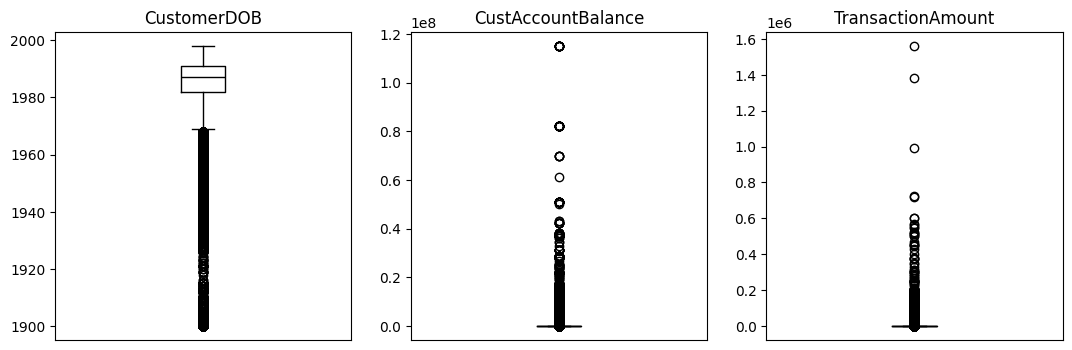

In [ ]:
# делаем проверку на выбросы с помощью boxplot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))

bplot1 = ax1.boxplot(df1['CustomerDOB'].dt.year, medianprops=dict(color="black"))
ax1.set_xticks([])
ax1.set_title('CustomerDOB')

bplot2 = ax2.boxplot(df1['CustAccountBalance'], medianprops=dict(color="black"))
ax2.set_xticks([])
ax2.set_title('CustAccountBalance')

bplot3 = ax3.boxplot(df1['TransactionAmount (INR)'], medianprops=dict(color="black"))
ax3.set_xticks([])
ax3.set_title('TransactionAmount')

plt.show()

* Выбросы в колонке СustomerDOB были уже обработаны на прошлом шаге.
* В колонках CustAccountBalance и TransactionAmount есть несколько записей с более высокими значениями, однако их можно интерпретировать как показатели для более премиальных клиентов банка, с большим остатком на счете и большим количеством транзакций. Так как эта группа нам потенциально нужна для сегментации, мы не будем удалять эти выбросы

In [ ]:
#droping the outliers
#df2 = df1[df1['CustomerDOB']!= '1800-01-01']
#df2.reset_index(drop=True, inplace=True)
#df2.head()

#### Создание новых признаков (Feature engineering)

In [ ]:
# Создадим колонку CustAge с возрастом
df1['CustAge'] = df1['TransactionDate'].dt.year - df1['CustomerDOB'].dt.year
df1['CustAge'].describe()

,CustAge
count,984634.000000
mean,31.129830
std,9.071289
min,18.000000
25%,25.000000
50%,29.000000
75%,34.000000
max,116.000000


In [ ]:
# Создадим колонку TransactionDateTime с полной датой операции

df1['TransactionDateTime'] = pd.to_datetime(
    df1['TransactionDate'].dt.strftime('%Y-%m-%d') + ' ' + df1['TransactionTime'].astype(str),
    errors='coerce')

print(df1['TransactionDateTime'].dtype)

datetime64[ns]


In [ ]:
# Создадим колонку TransactionDayOfWeek с днем недели
df1['TransactionDayOfWeek'] = df1['TransactionDate'].dt.strftime('%A')
df1['TransactionDayOfWeek'].value_counts()

,count
TransactionDayOfWeek,
Sunday,163059
Monday,145581
Thursday,141729
Saturday,140338
Tuesday,136018
Wednesday,132782
Friday,125127


#### Удаление ненужных столбцов

In [ ]:
# Отбросим колонку CustomerDOB(поскольку она нам больше неинформативна и у нас создана колонка Age)

df1 = df1.drop(columns=['CustomerDOB'])
df1.head()

,TransactionID,CustomerID,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),CustAge,TransactionDateTime,TransactionDayOfWeek
0,T1,C5841053,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,22,2016-08-02 14:32:07,Tuesday
1,T2,C2142763,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,59,2016-08-02 14:18:58,Tuesday
2,T3,C4417068,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,20,2016-08-02 14:27:12,Tuesday
3,T4,C5342380,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,43,2016-08-02 14:27:14,Tuesday
4,T5,C9031234,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,28,2016-08-02 18:11:56,Tuesday


In [ ]:
df1 = df1.iloc[:, [0, 7, 1, 2, 3, 6, 4, 5, 8, 9, 10]]
df1.head()

,TransactionID,TransactionAmount (INR),CustomerID,CustGender,CustLocation,TransactionTime,CustAccountBalance,TransactionDate,CustAge,TransactionDateTime,TransactionDayOfWeek
0,T1,25.0,C5841053,F,JAMSHEDPUR,14:32:07,17819.05,2016-08-02,22,2016-08-02 14:32:07,Tuesday
1,T2,27999.0,C2142763,M,JHAJJAR,14:18:58,2270.69,2016-08-02,59,2016-08-02 14:18:58,Tuesday
2,T3,459.0,C4417068,F,MUMBAI,14:27:12,17874.44,2016-08-02,20,2016-08-02 14:27:12,Tuesday
3,T4,2060.0,C5342380,F,MUMBAI,14:27:14,866503.21,2016-08-02,43,2016-08-02 14:27:14,Tuesday
4,T5,1762.5,C9031234,F,NAVI MUMBAI,18:11:56,6714.43,2016-08-02,28,2016-08-02 18:11:56,Tuesday


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 984634 entries, 0 to 1041613
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            984634 non-null  object        
 1   TransactionAmount (INR)  984634 non-null  float64       
 2   CustomerID               984634 non-null  object        
 3   CustGender               984634 non-null  object        
 4   CustLocation             984634 non-null  object        
 5   TransactionTime          984634 non-null  object        
 6   CustAccountBalance       984634 non-null  float64       
 7   TransactionDate          984634 non-null  datetime64[ns]
 8   CustAge                  984634 non-null  int32         
 9   TransactionDateTime      984634 non-null  datetime64[ns]
 10  TransactionDayOfWeek     984634 non-null  object        
dtypes: datetime64[ns](2), float64(2), int32(1), object(6)
memory usage: 86.4+ MB


### 3. EDA

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 984634 entries, 0 to 1041613
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            984634 non-null  object        
 1   TransactionAmount (INR)  984634 non-null  float64       
 2   CustomerID               984634 non-null  object        
 3   CustGender               984634 non-null  object        
 4   CustLocation             984634 non-null  object        
 5   TransactionTime          984634 non-null  object        
 6   CustAccountBalance       984634 non-null  float64       
 7   TransactionDate          984634 non-null  datetime64[ns]
 8   CustAge                  984634 non-null  int32         
 9   TransactionDateTime      984634 non-null  datetime64[ns]
 10  TransactionDayOfWeek     984634 non-null  object        
dtypes: datetime64[ns](2), float64(2), int32(1), object(6)
memory usage: 86.4+ MB


#### Univariate analysis

##### Демографические показатели

In [ ]:
# датасет уникальных пользователей
cust = df1.drop_duplicates(subset=['CustomerID'], keep='first').reset_index(drop=True).drop(['CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)', 'TransactionDayOfWeek'], axis=1)
print(cust.shape)
cust.head()

(838576, 6)


,TransactionID,CustomerID,CustGender,CustLocation,CustAge,TransactionDateTime
0,T1,C5841053,F,JAMSHEDPUR,22,2016-08-02 14:32:07
1,T2,C2142763,M,JHAJJAR,59,2016-08-02 14:18:58
2,T3,C4417068,F,MUMBAI,20,2016-08-02 14:27:12
3,T4,C5342380,F,MUMBAI,43,2016-08-02 14:27:14
4,T5,C9031234,F,NAVI MUMBAI,28,2016-08-02 18:11:56


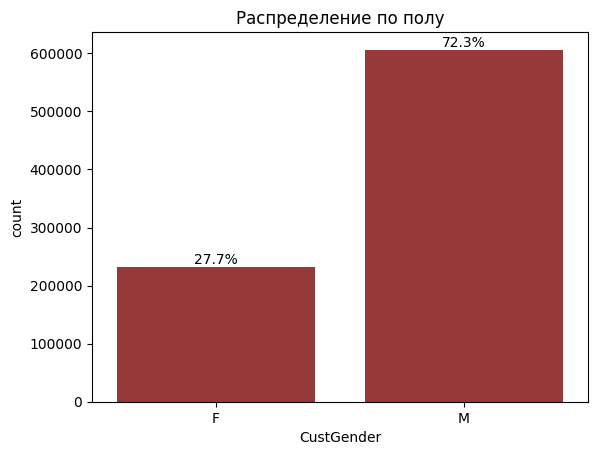

In [ ]:
# Gender
ax = sns.countplot(x='CustGender', data=cust, color='brown')
ax.set_title('Распределение по полу')

total = len(cust)
for p in ax.patches:
    count = int(p.get_height())
    pct = round(count / total * 100, 1)
    ax.annotate(f'{pct}%', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=10)

plt.show()

В банке клиентов мужского пола значительно больше, чем женского пола.

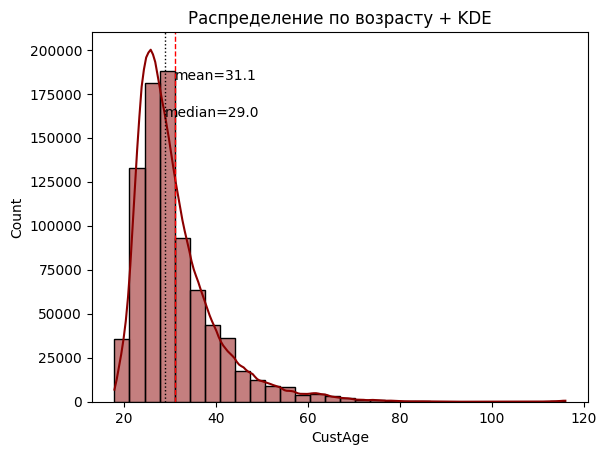

In [ ]:
# Age
plt.figure()
sns.histplot(cust['CustAge'], bins=30, kde=True, color='darkred')
plt.title("Распределение по возрасту + KDE")
plt.axvline(cust['CustAge'].mean(), color='red', linestyle='--', linewidth=1)
plt.text(cust['CustAge'].mean(), plt.ylim()[1]*0.9, f"mean={cust['CustAge'].mean():.1f}", ha='left', va='top')
plt.axvline(cust['CustAge'].median(), color='black', linestyle=':', linewidth=1)
plt.text(cust['CustAge'].median(), plt.ylim()[1]*0.8, f"median={cust['CustAge'].median():.1f}", ha='left', va='top')
plt.show()

Большинство клиентов банка находятся в возрасте от 20 до 35 лет. При этом, явно выражен правый хвост

##### Транзакционные показатели

In [ ]:
print(f"Промежуток транзакций: с {df1['TransactionDateTime'].min()} по {df1['TransactionDateTime'].max()}")

Промежуток транзакций: с 2016-08-01 00:00:05 по 2016-10-21 22:48:48


In [ ]:
# TransactionDateTime
hour = df1[['TransactionDate', 'TransactionTime']]
hour['TransactionTime'] = hour['TransactionTime'].astype(str).str[:2]

total_hourly_count = hour.groupby('TransactionTime')['TransactionDate'].count()
total_hourly_count = total_hourly_count.reset_index(drop=False).rename(columns={'TransactionDate': 'No. of Transactions'})
total_hourly_count.head()

,TransactionTime,No. of Transactions
0,00,16875
1,01,8258
2,02,5148
3,03,4366
4,04,4229


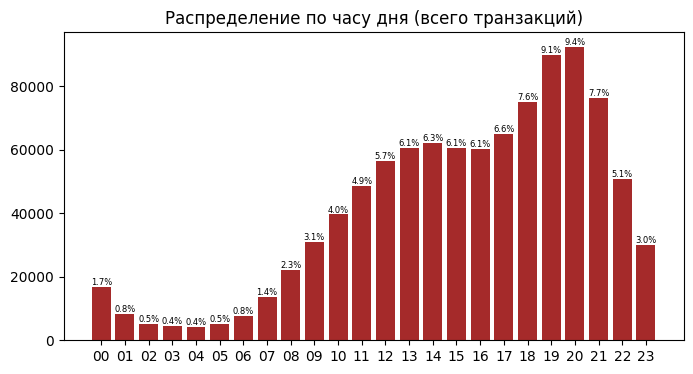

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(total_hourly_count['TransactionTime'], total_hourly_count['No. of Transactions'], color='brown')
ax.set_title('Распределение по часу дня (всего транзакций)', fontsize=12)

total = len(df1)
for p in ax.patches:
    count = int(p.get_height())
    pct = round(count / total * 100, 1)
    ax.annotate(f'{pct}%', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=6)

plt.show()

Большинство транзакций выпадает на период с 10 до 22. Пик транзакций, при этом, в 18 - 21 часы.

In [ ]:
# TransactionDayOfWeek
day = df1[['TransactionDate', 'TransactionDayOfWeek']]
daily_count = day.groupby('TransactionDayOfWeek').agg({'TransactionDate': lambda x: x.count() / x.nunique()}).rename(columns={'TransactionDate': 'Avg No. of Transactions'})
daily_count['Avg No. of Transactions'] = round(daily_count['Avg No. of Transactions'], 0)
daily_count = daily_count.reset_index(drop=False)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_count['TransactionDayOfWeek'] = pd.Categorical(daily_count['TransactionDayOfWeek'], categories=day_order, ordered=True)
daily_count.sort_values('TransactionDayOfWeek', inplace =True)

daily_count

,TransactionDayOfWeek,Avg No. of Transactions
1,Monday,18198.0
5,Tuesday,17002.0
6,Wednesday,18969.0
4,Thursday,17716.0
0,Friday,13903.0
2,Saturday,23390.0
3,Sunday,18118.0


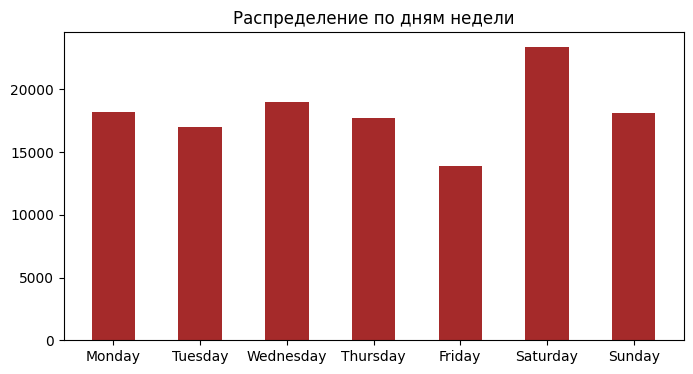

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(daily_count['TransactionDayOfWeek'], daily_count['Avg No. of Transactions'], width=0.5, color = 'brown')
ax.set_title('Распределение по дням недели', fontsize=12)

plt.show()

Больше всего транзакций происходит в выходные дни, особенно в субботу. В рабочие дни наименьшее количество транзакций происходит в пятницу

In [ ]:
# Transaction amount
df1['TransactionAmount (INR)'].describe()

,TransactionAmount (INR)
count,9.846340e+05
mean,1.452434e+03
std,6.140298e+03
min,0.000000e+00
25%,1.510000e+02
50%,4.312050e+02
75%,1.125000e+03
max,1.560035e+06


In [ ]:
df1[df1['TransactionAmount (INR)']==0]['TransactionID'].count()

np.int64(708)

708 транзакций были пустыми!

In [ ]:
# Location
df1['CustLocation'] = df1['CustLocation'].str.title()
df1['CustLocation'] = df1['CustLocation'].str.replace('[()]', '', regex=True)
df1['CustLocation'].value_counts().head(10)

,count
CustLocation,
Mumbai,97614
Bangalore,77698
New Delhi,76327
Gurgaon,70505
Delhi,67283
Noida,31665
Chennai,27498
Pune,24478
Hyderabad,21817


In [ ]:
trans_by_location = df1.groupby('CustLocation')['CustomerID'].count().sort_values(ascending=False)
trans_by_location = trans_by_location.to_frame().reset_index()
trans_by_location.columns = ['CustLocation', 'No_of_Transactions']

cust_by_location = df1.groupby('CustLocation')['CustomerID'].nunique().sort_values(ascending=False)
cust_by_location = cust_by_location.to_frame().reset_index()
cust_by_location.columns = ['CustLocation', 'No_of_Customers']

merged_by_location = pd.merge(trans_by_location, cust_by_location, on='CustLocation', how='outer')

total_tx = merged_by_location['No_of_Transactions'].sum()
merged_by_location['%_of_Transactions_from_Total'] = (merged_by_location['No_of_Transactions'] / total_tx * 100).round(2)
merged_by_location = merged_by_location.sort_values(by='No_of_Transactions', ascending=False).reset_index(drop=True)
merged_by_location.head(10)

,CustLocation,No_of_Transactions,No_of_Customers,%_of_Transactions_from_Total
0,Mumbai,97614,95973,9.91
1,Bangalore,77698,76595,7.89
2,New Delhi,76327,75241,7.75
3,Gurgaon,70505,69610,7.16
4,Delhi,67283,66435,6.83
5,Noida,31665,31462,3.22
6,Chennai,27498,27350,2.79
7,Pune,24478,24355,2.49
8,Hyderabad,21817,21710,2.22
9,Thane,20997,20899,2.13


#### Bivariate analysis


##### Взаимосвязь возраста с величиной транзакций и балансом на счете

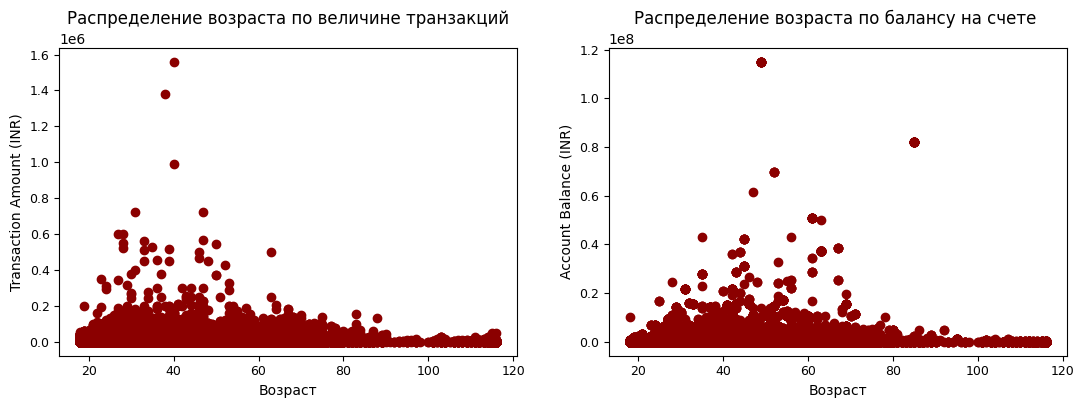

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

#по величине транзакций
ax1.scatter(df1['CustAge'], df1['TransactionAmount (INR)'], color='darkred')
ax1.set_title('Распределение возраста по величине транзакций')
ax1.set_ylabel('Transaction Amount (INR)', fontsize=10)

#по балансу на счете
ax2.scatter(df1['CustAge'], df1['CustAccountBalance'], color='darkred')
ax2.set_title('Распределение возраста по балансу на счете ')
ax2.set_ylabel('Account Balance (INR)', fontsize=10)

for axis in (ax1, ax2):
    axis.set_xlabel('Возраст', fontsize=10)
    axis.tick_params(axis='both', labelsize=9)

plt.show()

Можно заметить, что четкой корреляции и тренда между возрастом и транзакциями в данной визуализации нет. Попробуем посмотреть что будет, если разделить клиентов на возрастные группы

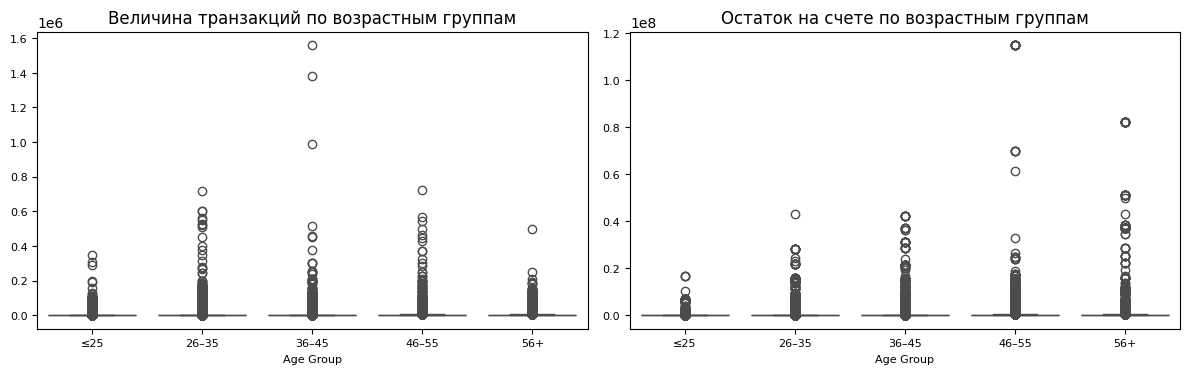

In [ ]:
df_age = df1.copy()
df_age['AgeGroup'] = pd.cut(df_age['CustAge'], [0,25,35,45,55,120], labels=['≤25','26–35','36–45','46–55','56+'])

fig, ax = plt.subplots(1,2, figsize=(12,4), sharex=False)

sns.boxplot(data=df_age, x='AgeGroup', y='TransactionAmount (INR)', ax=ax[0])
ax[0].set_title('Величина транзакций по возрастным группам');
ax[0].set_xlabel('Age Group', fontsize=8)

sns.boxplot(data=df_age, x='AgeGroup', y='CustAccountBalance', ax=ax[1])
ax[1].set_title('Остаток на счете по возрастным группам');
ax[1].set_xlabel('Age Group', fontsize=8)

for a in ax:
  a.set_ylabel('')
  a.tick_params(labelsize=8)

plt.tight_layout();
plt.show()

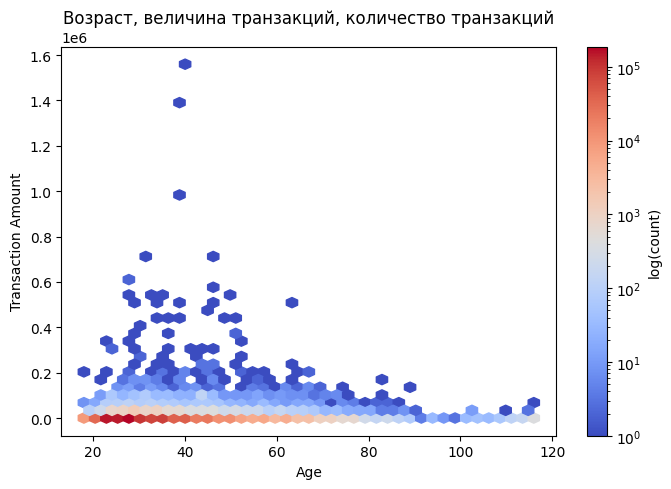

In [ ]:
plt.figure(figsize=(7,5))
plt.hexbin(df1['CustAge'], df1['TransactionAmount (INR)'], gridsize=40, bins='log', cmap='coolwarm')
plt.xlabel('Age')
plt.ylabel('Transaction Amount')
plt.title('Возраст, величина транзакций, количество транзакций')
plt.colorbar(label='log(count)')
plt.tight_layout()
plt.show()

##### Взаимосвязь пола с величиной транзакций и балансом на счете

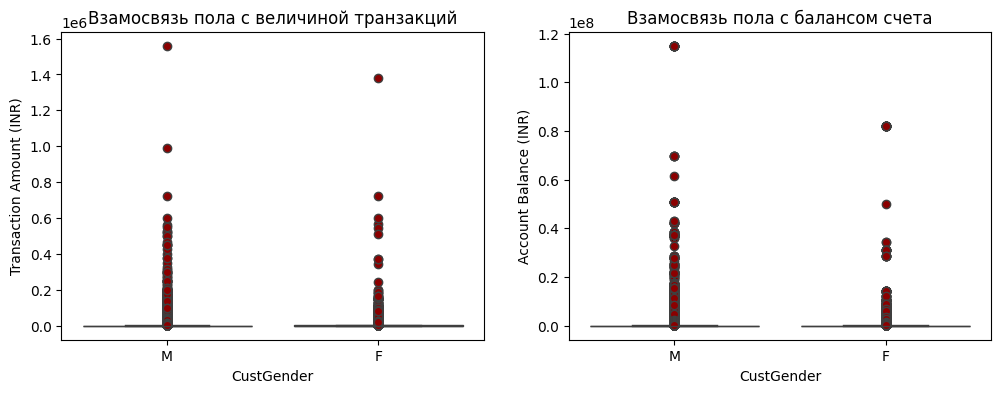

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#по величине транзакций
box_plot1 = sns.boxplot(data=df1, x='CustGender', y='TransactionAmount (INR)',
            flierprops={"marker": "o", "markerfacecolor": "darkred"},
            order=["M", "F"], ax=axes[0])
box_plot1.set_title('Взамосвязь пола с величиной транзакций', fontsize=12)
box_plot1.set_ylabel('Transaction Amount (INR)', fontsize=10)

#по балансу на счете
box_plot2 = sns.boxplot(data=df1, x='CustGender', y='CustAccountBalance',
            flierprops={"marker": "o", "markerfacecolor": "darkred"},
            order=["M", "F"], ax=axes[1])
box_plot2.set_title('Взамосвязь пола с балансом счета', fontsize=12)
box_plot2.set_ylabel('Account Balance (INR)', fontsize=10)

plt.show()

In [ ]:
print('Median transaction amount for men:', df1[df1['CustGender']=='M']['TransactionAmount (INR)'].median())
print('Median transaction amount for women:', df1[df1['CustGender']=='F']['TransactionAmount (INR)'].median())
print()
print('Mean transaction amount for men:', round(df1[df1['CustGender']=='M']['TransactionAmount (INR)'].mean(), 2))
print('Mean transaction amount for women:', round(df1[df1['CustGender']=='F']['TransactionAmount (INR)'].mean(), 2))

Median transaction amount for men: 399.0
Median transaction amount for women: 502.0

Mean transaction amount for men: 1396.57
Mean transaction amount for women: 1598.28


In [ ]:
print('Median account balance for men:', df1[df1['CustGender']=='M']['CustAccountBalance'].median())
print('Median account balance for women:', df1[df1['CustGender']=='F']['CustAccountBalance'].median())
print()
print('Mean account balance for men:', round(df1[df1['CustGender']=='M']['CustAccountBalance'].mean(), 2))
print('Mean account balance for women:', round(df1[df1['CustGender']=='F']['CustAccountBalance'].mean(), 2))

Median account balance for men: 14589.6
Median account balance for women: 20173.66

Mean account balance for men: 107885.92
Mean account balance for women: 101500.87


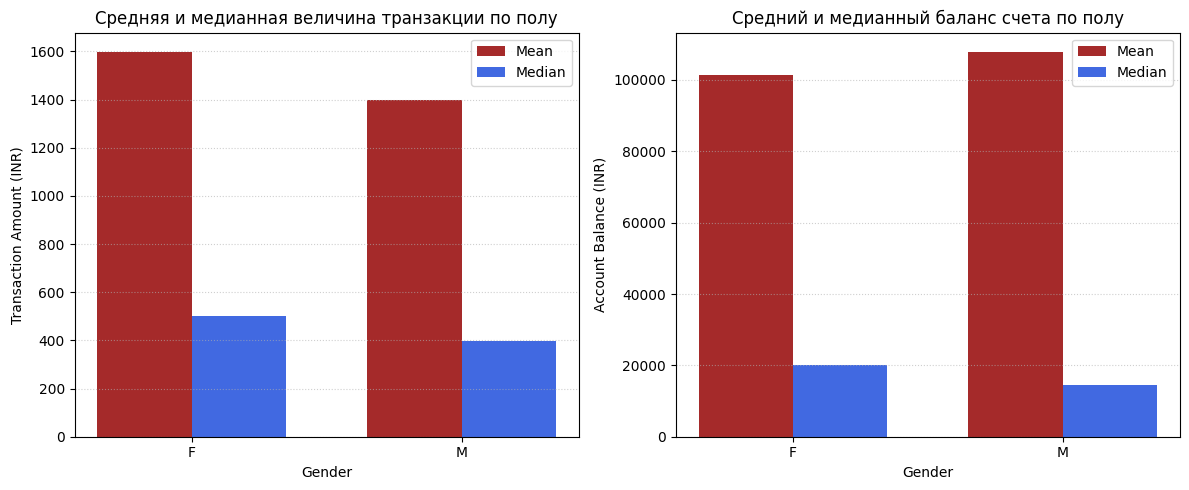

In [ ]:
# группируем данные по полу
grouped = df1.groupby('CustGender').agg(
    {'TransactionAmount (INR)': ['mean', 'median'], 'CustAccountBalance': ['mean', 'median']}).round(2)
grouped.columns = ['Mean_TransAmount', 'Median_TransAmount', 'Mean_AccountBalance', 'Median_AccountBalance']
grouped = grouped.reset_index()

# построение bar plot
x = range(len(grouped['CustGender']))
width = 0.35
colors = ['brown','royalblue']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.style.use('seaborn-v0_8-deep')

# Transaction Amount
axes[0].bar([p - width/2 for p in x], grouped['Mean_TransAmount'], width, label='Mean', color=colors[0])
axes[0].bar([p + width/2 for p in x], grouped['Median_TransAmount'], width, label='Median', color=colors[1])
axes[0].set_title('Средняя и медианная величина транзакции по полу')
axes[0].set_ylabel('Transaction Amount (INR)')

# Account Balance
axes[1].bar([p - width/2 for p in x], grouped['Mean_AccountBalance'], width, label='Mean', color=colors[0])
axes[1].bar([p + width/2 for p in x], grouped['Median_AccountBalance'], width, label='Median', color=colors[1])
axes[1].set_title('Средний и медианный баланс счета по полу')
axes[1].set_ylabel('Account Balance (INR)')

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(grouped['CustGender'])
    ax.set_xlabel('Gender')
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

##### Взаимосвязь локации с величиной транзакций

In [ ]:
loc_trans_stats = (df1.groupby('CustLocation')['TransactionAmount (INR)'].agg(['count', 'min', 'max', 'mean', 'median'])
    .round(2).reset_index().sort_values('mean', ascending=False))

total_tx = loc_trans_stats['count'].sum()
loc_trans_stats['%_of_Transactions'] = (loc_trans_stats['count'] / total_tx * 100).round(5)
loc_trans_stats = loc_trans_stats.sort_values(by='%_of_Transactions', ascending=False).reset_index(drop=True)
loc_trans_stats.head(10)

,CustLocation,count,min,max,mean,median,%_of_Transactions
0,Mumbai,97614,0.0,724122.00,1653.83,555.00,9.91373
1,Bangalore,77698,0.0,500000.00,1357.33,430.00,7.89105
2,New Delhi,76327,0.0,991132.22,1709.97,500.00,7.75181
3,Gurgaon,70505,0.0,1560034.99,1434.69,471.75,7.16053
4,Delhi,67283,0.0,569500.27,1382.15,450.00,6.83330
5,Noida,31665,0.0,600008.32,1322.87,438.00,3.21592
6,Chennai,27498,0.0,265414.00,1390.82,451.00,2.79271
7,Pune,24478,0.0,1380002.88,1427.21,424.00,2.48600
8,Hyderabad,21817,0.0,450000.00,1414.42,399.00,2.21575
9,Thane,20997,0.0,140000.00,1214.72,459.00,2.13247


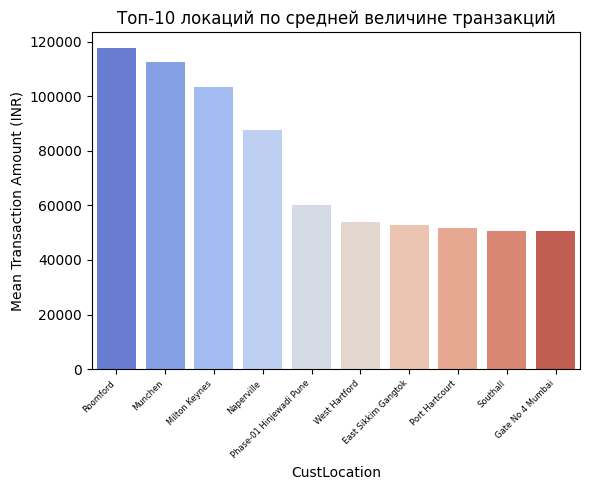

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(data=loc_trans_stats.sort_values('mean', ascending=False)[:10], x='CustLocation', y='mean', palette='coolwarm')
plt.title('Топ-10 локаций по средней величине транзакций')
plt.ylabel('Mean Transaction Amount (INR)')
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.tight_layout()
plt.show()

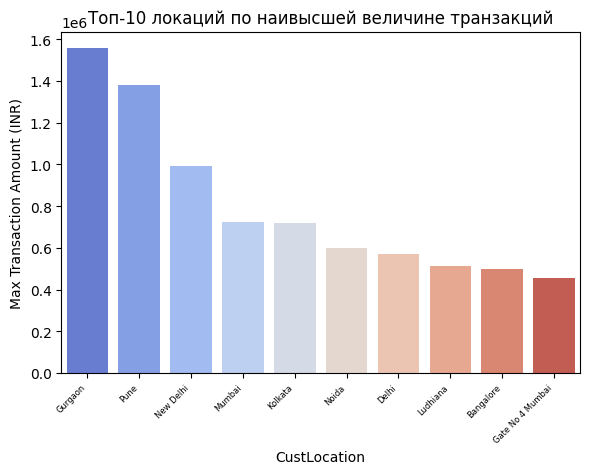

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(data=loc_trans_stats.sort_values('max', ascending=False)[:10], x='CustLocation', y='max', palette='coolwarm')
plt.title('Топ-10 локаций по наивысшей величине транзакций')
plt.ylabel('Max Transaction Amount (INR)')
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
loc = (df1.groupby('CustLocation')['TransactionAmount (INR)'].agg(count='count', mean='mean', median='median', std='std',
                                                                  p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75), p90=lambda s: s.quantile(.90)).reset_index())

# Клиенты и частота
cust_cnt = df1.groupby('CustLocation')['CustomerID'].nunique().reset_index(name='n_customers')
loc = loc.merge(cust_cnt, on='CustLocation', how='left')
loc['tx_per_customer'] = loc['count'] / loc['n_customers'].replace(0, np.nan)

# Доп. метрики
loc['iqr'] = loc['p75'] - loc['p25'] # вариативность
loc['skew_proxy'] = loc['median'] / loc['mean'] # <1 → правый хвост
loc['hi_share'] = (df1.assign(is_hi=df1.groupby('CustLocation')['TransactionAmount (INR)'].transform(lambda s: s > s.quantile(.90)))
.groupby('CustLocation')['is_hi'].mean().reset_index(drop=True))

# Топ-50 по активности
loc50 = (loc.sort_values('count', ascending=False).head(50).reset_index(drop=True))

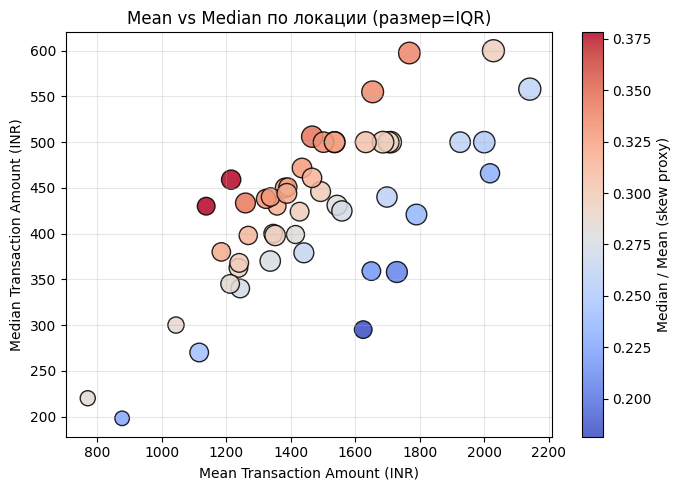

In [ ]:
plt.figure(figsize=(7,5))
sc = plt.scatter(loc50['mean'], loc50['median'],s=np.clip(loc50['iqr'] / 5, 20, 800),
                 c=loc50['skew_proxy'], cmap='coolwarm', alpha=0.85, edgecolor='k')
plt.colorbar(sc, label='Median / Mean (skew proxy)')
plt.xlabel('Mean Transaction Amount (INR)')
plt.ylabel('Median Transaction Amount (INR)')
plt.title('Mean vs Median по локации (размер=IQR)')
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

##### Взаимосвязь времени транзакции с величиной транзакции

In [ ]:
df_time = df1.copy()
df_time['TransactionDateTime'] = pd.to_datetime(df_time['TransactionDateTime'], errors='coerce')
df_time['Hour'] = df_time['TransactionDateTime'].dt.hour
df_time['Minute'] = df_time['TransactionDateTime'].dt.minute
df_time['Weekday'] = df_time['TransactionDateTime'].dt.day_name()

# Сегменты времени суток
df_time['TimeSegment'] = pd.cut(df_time['Hour'], bins=[0,6,12,18,24], right=False, include_lowest=True,
                                labels=['Night (0–6)','Morning (6–12)','Afternoon (12–18)','Evening (18–24)'])

# Бины возраста (для некоторых графиков)
df_time['AgeGroup'] = pd.cut(df_time['CustAge'], [0,25,35,45,55,120],labels=['≤25','26–35','36–45','46–55','56+'])

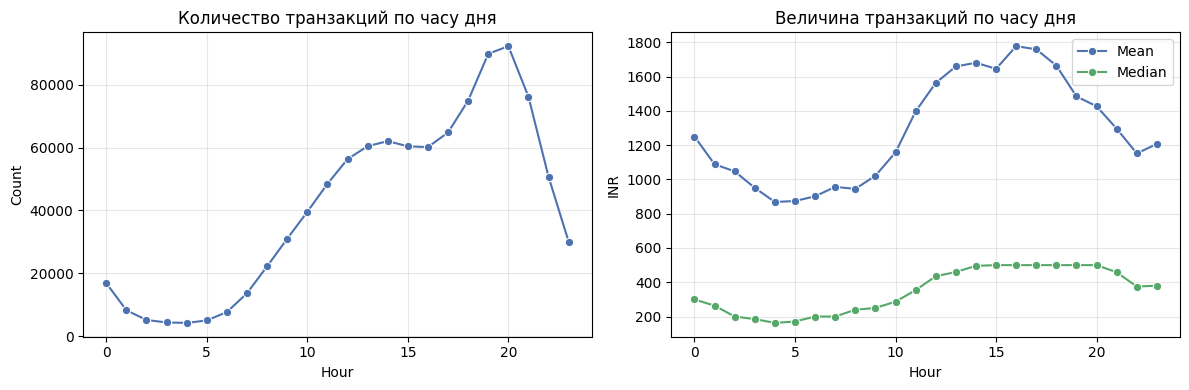

In [ ]:
tx_by_hour = (df_time.groupby('Hour')['TransactionAmount (INR)'].agg(mean='mean', median='median', count='count').reset_index())

fig, ax = plt.subplots(1, 2, figsize=(12,4), sharex=True)

sns.lineplot(data=tx_by_hour, x='Hour', y='count', marker='o', ax=ax[0])
ax[0].set_title('Количество транзакций по часу дня')
ax[0].set_ylabel('Count')
ax[0].grid(alpha=.3)

sns.lineplot(data=tx_by_hour, x='Hour', y='mean', marker='o', ax=ax[1], label='Mean')
sns.lineplot(data=tx_by_hour, x='Hour', y='median', marker='o', ax=ax[1], label='Median')
ax[1].set_title('Величина транзакций по часу дня')
ax[1].set_ylabel('INR'); ax[1].grid(alpha=.3)
ax[1].legend()

plt.tight_layout()
plt.show()

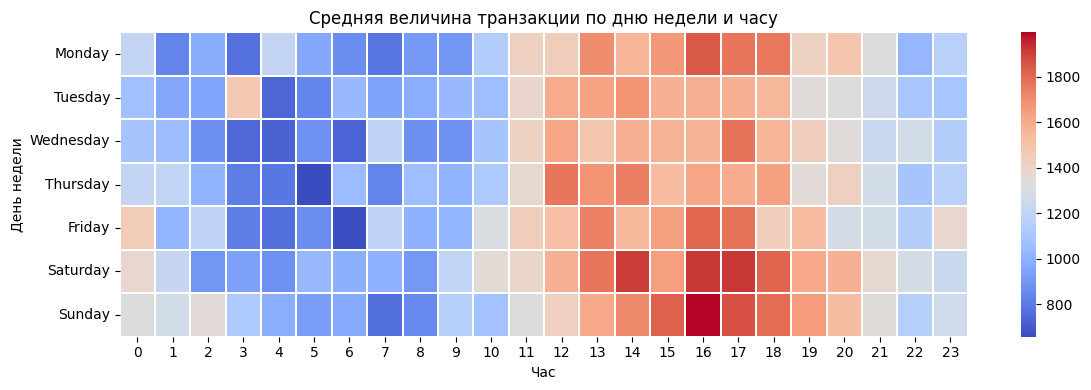

In [ ]:
tx_pivot_weekday_hour = df_time.pivot_table(index='Weekday', columns='Hour', values='TransactionAmount (INR)', aggfunc='mean').reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(12,4))
sns.heatmap(tx_pivot_weekday_hour, cmap='coolwarm', linewidths=.3)
plt.title('Средняя величина транзакции по дню недели и часу')
plt.xlabel('Час')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()

#### Multivariate analysis

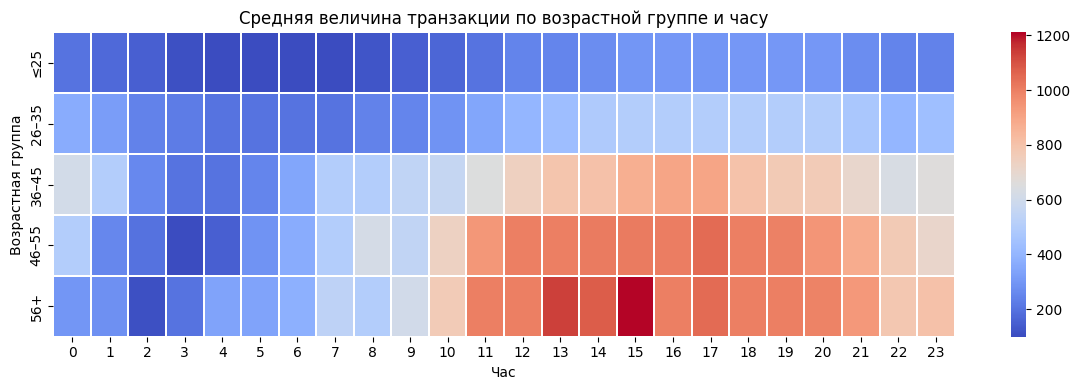

In [ ]:
tx_pivot_age_hour = df_time.pivot_table(index='AgeGroup', columns='Hour', values='TransactionAmount (INR)', aggfunc='median')

plt.figure(figsize=(12,4))
sns.heatmap(tx_pivot_age_hour, cmap='coolwarm', linewidths=.3)
plt.title('Средняя величина транзакции по возрастной группе и часу')
plt.xlabel('Час')
plt.ylabel('Возрастная группа')
plt.tight_layout()
plt.show()

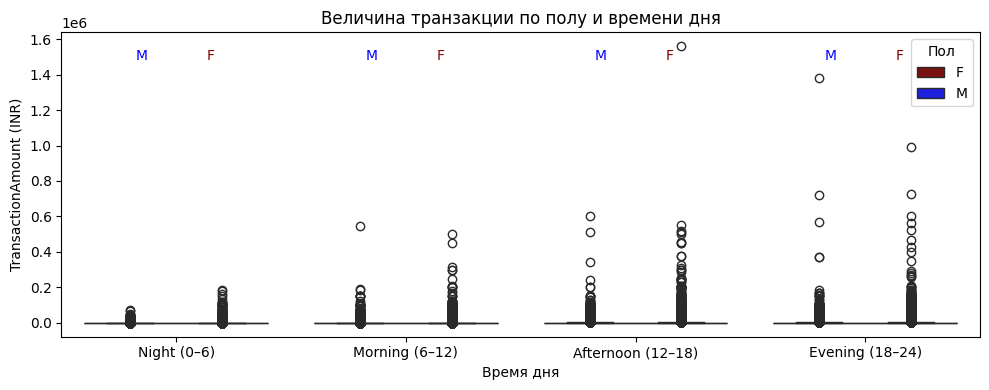

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df_time, x='TimeSegment', y='TransactionAmount (INR)', hue='CustGender', palette={'M':'blue', 'F':'darkred'})
plt.title('Величина транзакции по полу и времени дня')
plt.xlabel('Время дня')
plt.ylabel('TransactionAmount (INR)')

positions = range(len(df_time['TimeSegment'].unique()))
for i, pos in enumerate(positions):
    plt.text(i - 0.15, df_time['TransactionAmount (INR)'].max() * 0.95, 'M', color='blue', ha='center', fontsize=10)
    plt.text(i + 0.15, df_time['TransactionAmount (INR)'].max() * 0.95, 'F', color='darkred', ha='center', fontsize=10)

plt.legend(title='Пол', loc='upper right')
plt.tight_layout();
plt.show()

### Обучение. Сегментация клиентов с использованием различных моделей<a name='customer-segmentation'></a>

#### Предобработка данных<a name='data-preprocessing'></a>

In [ ]:
df_rfm = df1.copy()

df_rfm['TransactionDate1'] = df_rfm['TransactionDate']
df_rfm['TransactionDate2'] = df_rfm['TransactionDate']

# Группируем по клиенту и создаём агрегированный RFM-датафрейм
RFM_df = df_rfm.groupby('CustomerID').agg({
    'TransactionID': 'count',             # Frequency
    'CustGender': 'first',
    'CustLocation':'first',
    'CustAccountBalance': 'mean',
    'TransactionAmount (INR)': 'mean',    # Monetary
    'CustAge': 'median',
    'TransactionDate2': 'max',            # последняя транзакция
    'TransactionDate1': 'min'             # первая транзакция
}).reset_index()


RFM_df.rename(columns={
    'TransactionID': 'Frequency',
    'CustAge': 'CustomerAge'
}, inplace=True)

# Recency — разница между последней и первой транзакцией
RFM_df['Recency'] = RFM_df['TransactionDate2'] - RFM_df['TransactionDate1']

# Извлекаем количество дней
RFM_df['Recency'] = RFM_df['Recency'].astype(str)
RFM_df['Recency'] = RFM_df['Recency'].apply(lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0)

# Заменяем 0 дней (активных клиентов) на 1, чтобы не было деления на ноль
RFM_df['Recency'] = RFM_df['Recency'].apply(lambda x: 1 if x == 0 else x)


RFM_df.drop(columns=['TransactionDate1', 'TransactionDate2', 'CustomerID','CustLocation'], inplace=True)

RFM_df.head()

,Frequency,CustGender,CustAccountBalance,TransactionAmount (INR),CustomerAge,Recency
0,2,F,76340.635,2553.0,28.5,48
1,1,M,24204.490,1499.0,22.0,1
2,2,F,100112.950,727.5,28.0,6
3,1,F,496.180,30.0,26.0,1
4,1,M,87058.650,5000.0,51.0,1


Проверим Outliers

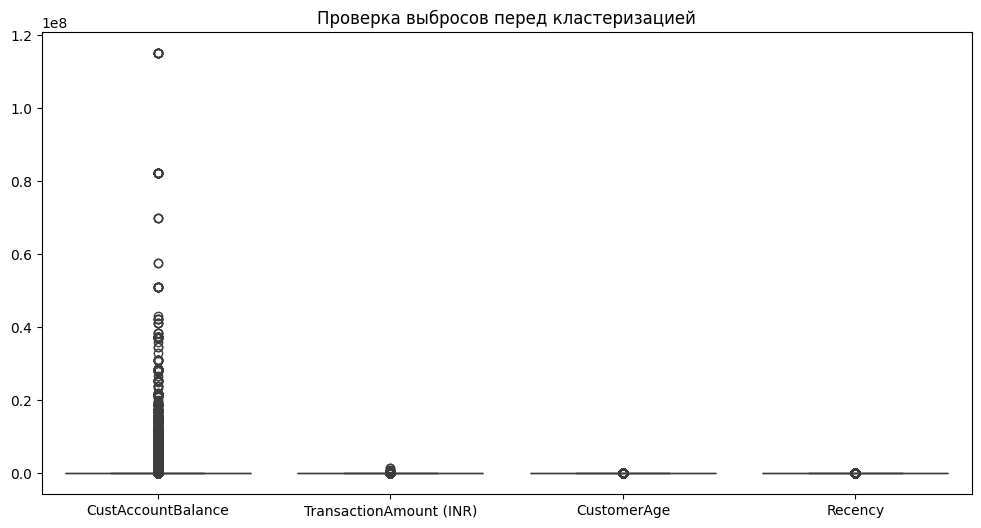

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=RFM_df[['CustAccountBalance', 'TransactionAmount (INR)', 'CustomerAge', 'Recency']])
plt.title('Проверка выбросов перед кластеризацией')
plt.show()

In [ ]:
for col in ['CustAccountBalance', 'TransactionAmount (INR)', 'CustomerAge']:
    upper_limit = RFM_df[col].quantile(0.99)
    lower_limit = RFM_df[col].quantile(0.01)
    RFM_df[col] = np.clip(RFM_df[col], lower_limit, upper_limit)

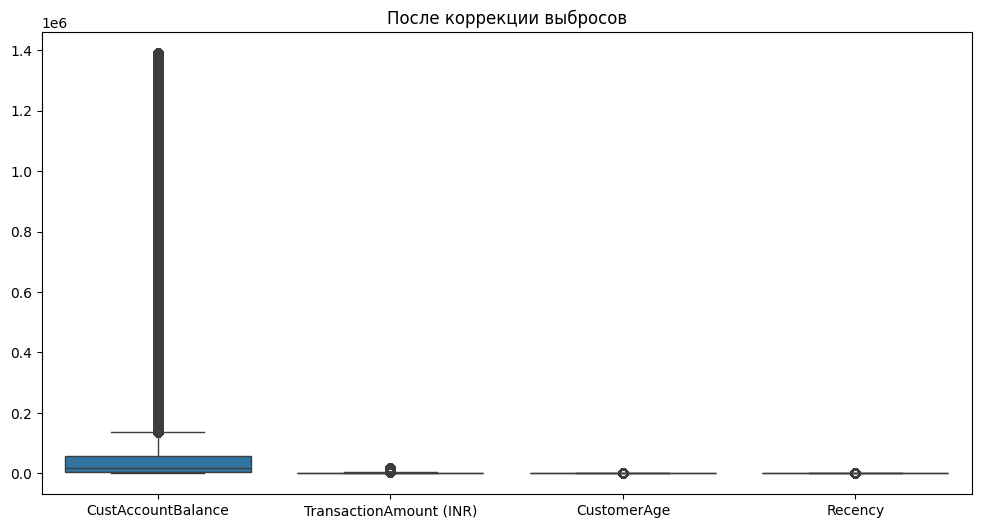

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=RFM_df[['CustAccountBalance', 'TransactionAmount (INR)', 'CustomerAge', 'Recency']])
plt.title('После коррекции выбросов')
plt.show()

Нормализация

In [ ]:
RFM_df['CustGender'] = RFM_df['CustGender'].map({'M': 1, 'F': 0})

rfm_final = RFM_df.sample(n=100000, random_state=20).reset_index(drop=True)

features_to_scale = ['Frequency', 'CustAccountBalance', 'TransactionAmount (INR)', 'CustomerAge', 'Recency']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm_final[features_to_scale])


rfm_scaled = pd.DataFrame(scaled_data, columns=features_to_scale)
rfm_scaled['CustGender'] = rfm_final['CustGender'].values

Ищем оптимальное число кластеров, необходимое для лучшей группировки клиентов. Определим это число с помощью методя локтя

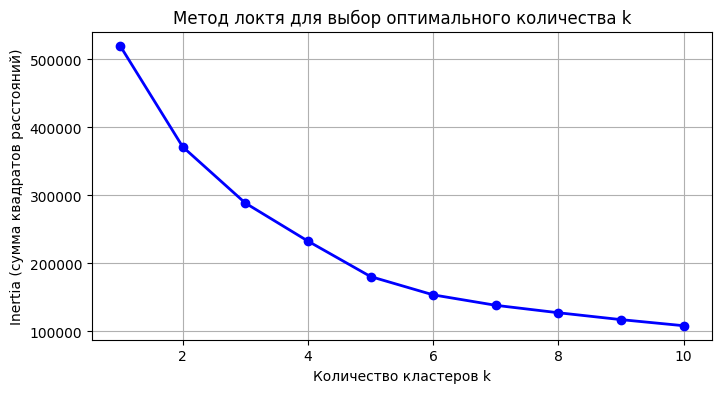

In [ ]:
inertia = []
K = range(1, 11)

for k in K:
  model = KMeans(n_clusters=k, random_state=42)
  model.fit(rfm_scaled)
  inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-', linewidth=2)
plt.title('Метод локтя для выбор оптимального количества k')
plt.xlabel('Количество кластеров k')
plt.ylabel('Inertia (сумма квадратов расстояний)')
plt.grid(True)
plt.show()

KMEANS

In [ ]:
# Обучаем KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=12, random_state=42)
labels = kmeans.fit_predict(rfm_scaled)
rfm_scaled['Cluster'] = labels

# Для интерпретации
rfm_final['Cluster'] = labels

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    RandomForestClassifier
)
from xgboost import XGBClassifier
# base tree
defaultTree = DecisionTreeClassifier(random_state=1)
defaultTree.fit(train_X, train_y)

# Bagging
bagging = BaggingClassifier( base_estimator=defaultTree, n_estimators=100,
                            random_state=1)
bagging.fit(train_X, train_y)

# AdaBoost (boosted decision trees)
boost = AdaBoostClassifier(
    base_estimator=defaultTree,
    n_estimators=100,
    algorithm='SAMME',
    random_state=1
)
boost.fit(train_X, train_y)

# Random Forest
rf = RandomForestClassifier(n_estimators=100,random_state=1)
rf.fit(train_X, train_y)

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=1, eval_metric="logloss")
xgb.fit(train_X, train_y)

Оценка результатов модели KMeans

In [ ]:
# Считаем метрики качества кластеризации
sil_score = silhouette_score(rfm_scaled, labels)
dbi_score = davies_bouldin_score(rfm_scaled, labels)
chi_score = calinski_harabasz_score(rfm_scaled, labels)

print('Метрики кластеризации:')
print(f'Silhouette Score: {sil_score:.4f}')
print(f'Davies-Bouldin Score: {dbi_score:.4f}')
print(f'Calinski-Harabasz Score: {chi_score:.4f}')

Метрики кластеризации:
Silhouette Score: 0.5765
Davies-Bouldin Score: 0.8206
Calinski-Harabasz Score: 45390.9145


In [ ]:
rfm_final['CustGender'] = rfm_final['CustGender'].map({1: 'M', 0: 'F'})
rfm_final.head()

,Frequency,CustGender,CustAccountBalance,TransactionAmount (INR),CustomerAge,Recency,Cluster
0,1,M,14761.91,26.00,30.0,1,1
1,1,F,25379.17,98.74,25.0,1,1
2,2,F,49221.47,2560.50,25.0,1,0
3,1,M,6316.03,900.00,27.0,1,1
4,1,F,4168.94,100.00,30.0,1,1


Построим еще одну модель для сравнения результатов.
GMM (Gaussian Mixture Model)

In [ ]:
sample_df = rfm_scaled.sample(n=50000, random_state=42)

gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
x = gmm.fit(sample_df)
sample_labels = gmm.predict(sample_df)

sil_score_gmm = silhouette_score(sample_df, sample_labels)
dbi_score_gmm = davies_bouldin_score(sample_df, sample_labels)
chi_score_gmm = calinski_harabasz_score(sample_df, sample_labels)

print('GMM (GaussianMixture) результаты:')
print()
print('Silhouette Score:', sil_score_gmm)
print('Davies–Bouldin:', dbi_score_gmm)
print('Calinski–Harabasz:', chi_score_gmm)

GMM (GaussianMixture) результаты:

Silhouette Score: 0.5450315544712089
Davies–Bouldin: 1.7992340248361378
Calinski–Harabasz: 14509.596185196844


Для сравнения была протестирована модель Gaussian Mixture Model (GMM).

Эта модель была выбрана, потому что она является наиболее близкой альтернативой K-Means — также выполняет кластеризацию, но на основе вероятностного подхода, что теоретически позволяет лучше работать с данными, где кластеры перекрываются или имеют сложную форму.

Другие методы кластеризации (например, DBSCAN или Agglomerative Clustering) в данном случае не подходят:

•	DBSCAN чувствителен к параметрам плотности и плохо работает с масштабированными банковскими данными большого объёма;

•	иерархическая кластеризация требует значительных вычислительных ресурсов при таком размере выборки и плохо масштабируется.

Поэтому для объективного сравнения мы ограничились GMM как наиболее релевантной альтернативой K-Means.

Однако результаты показали, что K-Means справляется с задачей значительно лучше — он быстрее, устойчивее и формирует чётко различимые кластеры, в то время как GMM дала размытые границы и слабые метрики.

### Анализ кластеров



In [ ]:
# Преобразую 'CustGender' опять в числовой формат перед расчетом средних
rfm_final['CustGender_numeric'] = rfm_final['CustGender'].map({'M': 1, 'F': 0})

# Смотрю средние значения по кластерам, исключая исходную строковую колонку CustGender
cluster_summary = rfm_final.groupby('Cluster')[['Frequency', 'CustAccountBalance', 'TransactionAmount (INR)', 'CustomerAge', 'Recency', 'CustGender_numeric']].mean().round(2)

# Переименую колонку обратно для удобства
cluster_summary.rename(columns={'CustGender_numeric': 'CustGender'}, inplace=True)

print('\nСредние значения по кластерам:')
display(cluster_summary)


Средние значения по кластерам:


,Frequency,CustAccountBalance,TransactionAmount (INR),CustomerAge,Recency,CustGender
Cluster,,,,,,
0,2.14,63815.31,1042.25,30.73,18.57,0.72
1,1.00,43874.62,807.56,30.53,1.00,0.72
2,1.10,976131.01,2163.55,40.01,2.40,0.74
3,1.12,126165.13,12778.78,36.07,2.70,0.70


In [ ]:
# Используем ненормализованные средние значения из cluster_summary
# Убедимся, что 'CustGender' в числовом формате (1 для M, 0 для F)
# Используем копию, чтобы не изменять исходный cluster_summary, если он нужен в другом месте
cluster_summary_numeric = cluster_summary.copy()

# Определяем атрибуты для графика (все колонки, кроме Cluster)
attributes = cluster_summary_numeric.columns.tolist()
# 'Cluster' является индексом, поэтому его нет в columns.tolist()


# Масштабируем cluster_summary_numeric для радар-графика
scaler_summary = StandardScaler()
scaled_cluster_summary = scaler_summary.fit_transform(cluster_summary_numeric[attributes])
scaled_cluster_summary = pd.DataFrame(scaled_cluster_summary, columns=attributes, index=cluster_summary_numeric.index)


# Определяем цвета и названия для 4 кластеров
colors = ['blue', 'red', 'green', 'purple']
cluster_names = [f'Cluster {i}' for i in scaled_cluster_summary.index]

fig = go.Figure()

# Строим радар-график для каждого кластера
for i in scaled_cluster_summary.index:
    # Выбираем средние значения атрибутов для текущего кластера из scaled_cluster_summary
    mean_values = scaled_cluster_summary.loc[i, attributes].values

    fig.add_trace(go.Scatterpolar(
        r=mean_values,
        theta=attributes,
        fill='toself',
        fillcolor=colors[i],
        opacity=0.6,
        name=cluster_names[i]
    ))

# Определяем динамический диапазон для радиальной оси на основе масштабированных данных
# Диапазон от минимального до максимального значения среди всех масштабированных средних
radial_axis_range = [scaled_cluster_summary.min().min() * 1.1, scaled_cluster_summary.max().max() * 1.1]


fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=radial_axis_range
        )),
    showlegend=True,
    title="Radar plot - Cluster attributes (Scaled Average Values)"
)
fig.show()

In [ ]:
print("Характеристики кластеров (средние значения):")

# Проходим по каждому кластеру в cluster_summary (который индексирован по номеру кластера)
for cluster_id in cluster_summary.index:
    print(f"\nКластер {cluster_id} Характеристики:")
    # Получаем строку с характеристиками для текущего кластера
    cluster_info = cluster_summary.loc[cluster_id]

    # Определяем доминирующий пол на основе строкового значения
    dominant_gender = cluster_info['CustGender'] # Теперь берем строковое значение напрямую

    # Выводим каждую характеристику из строки
    print(f"- Средняя Частота (Frequency): {cluster_info['Frequency']:.2f}")
    print(f"- Доминирующий Пол (CustGender): {dominant_gender}")
    print(f"- Средний Баланс Счета (CustAccountBalance): {cluster_info['CustAccountBalance']:.2f}")
    print(f"- Средняя Сумма Транзакций (TransactionAmount (INR)): {cluster_info['TransactionAmount (INR)']:.2f}")
    print(f"- Средний Возраст Клиента (CustomerAge): {cluster_info['CustomerAge']:.2f}")
    print(f"- Средняя Давность (Recency): {cluster_info['Recency']:.2f}")

Характеристики кластеров (средние значения):

Кластер 0 Характеристики:
- Средняя Частота (Frequency): 2.14
- Доминирующий Пол (CustGender): 0.72
- Средний Баланс Счета (CustAccountBalance): 63815.31
- Средняя Сумма Транзакций (TransactionAmount (INR)): 1042.25
- Средний Возраст Клиента (CustomerAge): 30.73
- Средняя Давность (Recency): 18.57

Кластер 1 Характеристики:
- Средняя Частота (Frequency): 1.00
- Доминирующий Пол (CustGender): 0.72
- Средний Баланс Счета (CustAccountBalance): 43874.62
- Средняя Сумма Транзакций (TransactionAmount (INR)): 807.56
- Средний Возраст Клиента (CustomerAge): 30.53
- Средняя Давность (Recency): 1.00

Кластер 2 Характеристики:
- Средняя Частота (Frequency): 1.10
- Доминирующий Пол (CustGender): 0.74
- Средний Баланс Счета (CustAccountBalance): 976131.01
- Средняя Сумма Транзакций (TransactionAmount (INR)): 2163.55
- Средний Возраст Клиента (CustomerAge): 40.01
- Средняя Давность (Recency): 2.40

Кластер 3 Характеристики:
- Средняя Частота (Frequency):

### Визуализация распределение признаков внутри каждого кластера


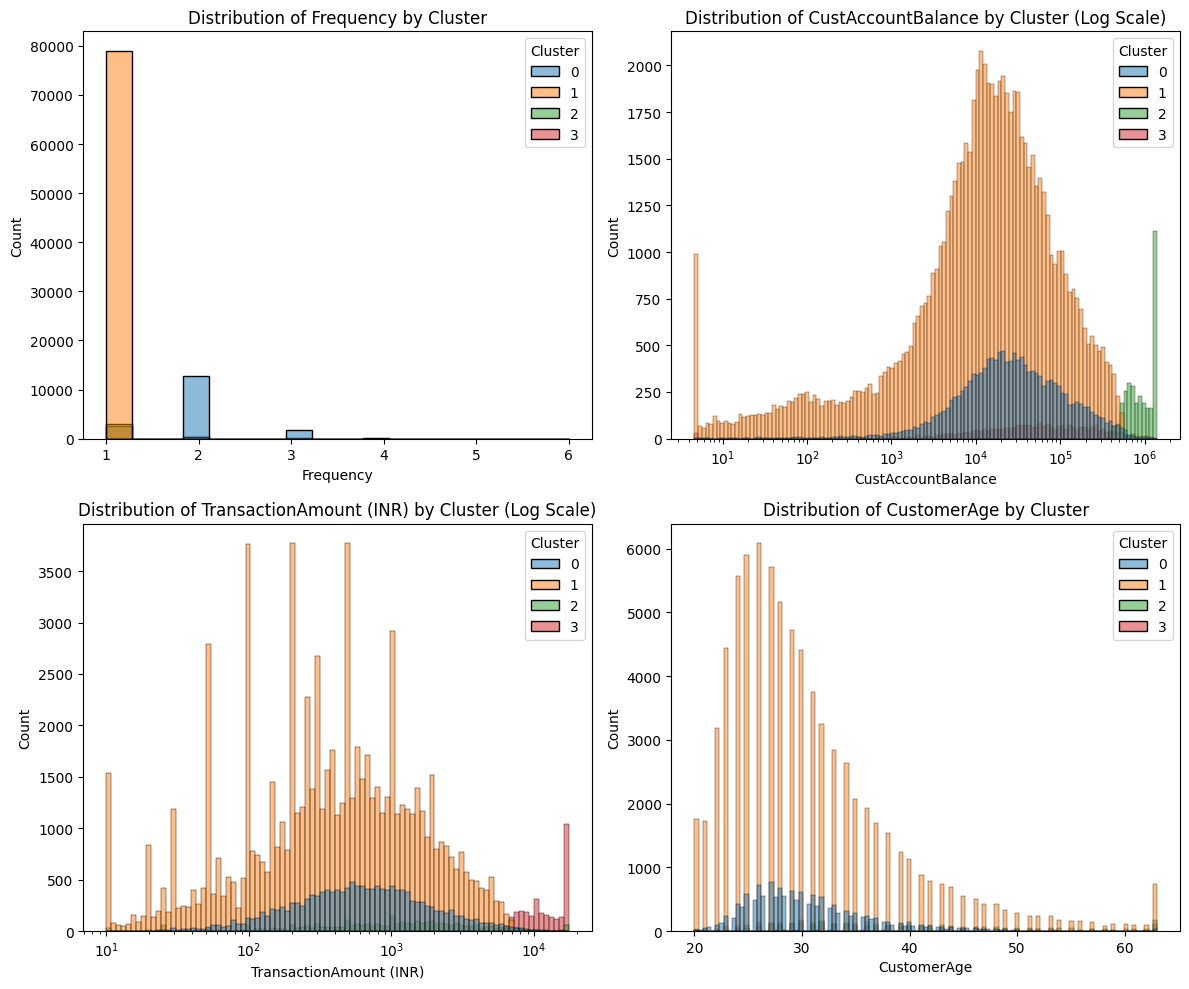

In [ ]:
features = ['Frequency', 'CustAccountBalance', 'TransactionAmount (INR)', 'CustomerAge']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

# Add a small constant to avoid issues with log scale on zero values
rfm_final_log = rfm_final.copy()
rfm_final_log['CustAccountBalance'] = rfm_final_log['CustAccountBalance'] + 1e-9
rfm_final_log['TransactionAmount (INR)'] = rfm_final_log['TransactionAmount (INR)'] + 1e-9


for i, col in enumerate(features):
    if col in ['CustAccountBalance', 'TransactionAmount (INR)']:
        sns.histplot(data=rfm_final_log, x=col, hue='Cluster', ax=axes[i], log_scale=True, palette='tab10') # Changed palette to 'tab10'
        axes[i].set_title(f'Distribution of {col} by Cluster (Log Scale)')
    else:
        sns.histplot(data=rfm_final_log, x=col, hue='Cluster', ax=axes[i], palette='tab10') # Changed palette to 'tab10'
        axes[i].set_title(f'Distribution of {col} by Cluster')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

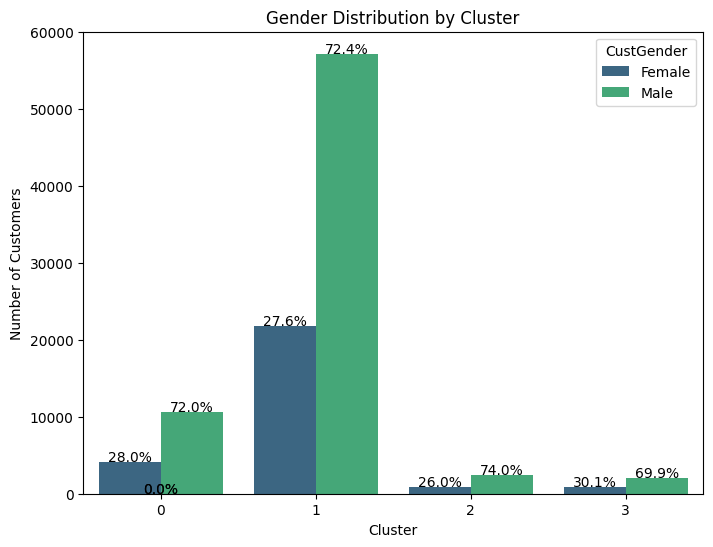

In [ ]:
# Create a bar plot for gender distribution across clusters
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=rfm_final, x='Cluster', hue='CustGender', palette='viridis')
plt.title('Gender Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1, 2, 3], labels=[0, 1, 2, 3])
plt.legend(title='CustGender', labels=['Female', 'Male'])

# Add percentage labels
total = rfm_final.groupby('Cluster')['CustGender'].count().reset_index()
for p in ax.patches:
    height = p.get_height()
    cluster = int(p.get_x() + p.get_width() / 2) if p.get_x() < 0 else int(p.get_x() + p.get_width() / 2 + 0.5) # Adjust for bar position
    cluster_total = total[total['Cluster'] == cluster]['CustGender'].iloc[0]
    percentage = f'{height / cluster_total * 100:.1f}%'
    ax.text(p.get_x() + p.get_width() / 2., height + 50, percentage, ha="center")

plt.show()

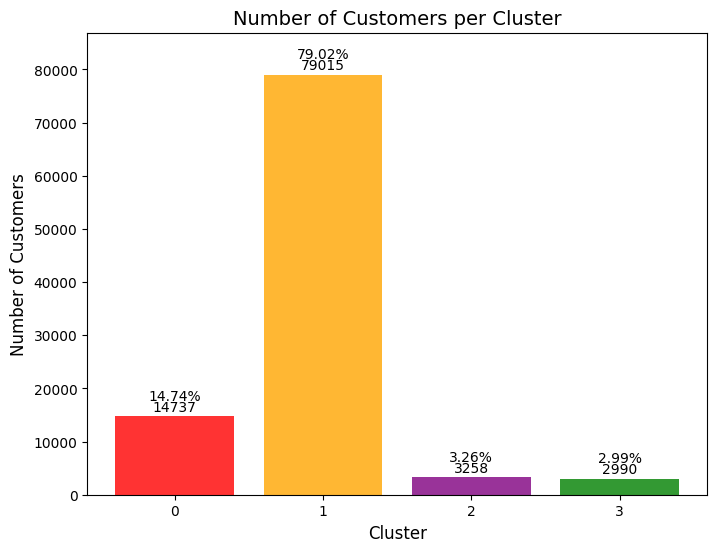

In [ ]:
# Считаем количество клиентов в каждом кластере из rfm_final
cluster_counts = rfm_final['Cluster'].value_counts().sort_index()

colours = ["red", "orange", "purple", "green"]

#to plot the number of customers per cluster
fig, ax = plt.subplots(figsize=(8, 6)) # Увеличил размер графика для лучшей читаемости
ax.bar(x=cluster_counts.index, height=cluster_counts.values, color=colours, alpha = 0.8)
ax.set_title('Number of Customers per Cluster', fontsize=14) # Увеличил размер заголовка
ax.set_xticks(cluster_counts.index) # Устанавливаем метки по индексам кластеров
ax.set_xlabel('Cluster', fontsize=12) # Увеличил размер подписи оси X
ax.set_ylabel('Number of Customers', fontsize=12) # Увеличил размер подписи оси Y
ax.tick_params(axis='both', labelsize=10) # Увеличил размер меток на осях
ax.margins(y=0.1)

#function to add labels above each bar
def addlabels():
    y = cluster_counts.values.tolist()
    total_customers = cluster_counts.sum() # Общее количество клиентов
    for i in range(len(cluster_counts.index.tolist())):
        # Добавляем количество клиентов
        plt.text(i, y[i] + total_customers * 0.01, y[i], ha='center', fontsize=10) # Небольшой отступ сверху
        # Добавляем процентное соотношение
        percentage = f'{round((y[i] / total_customers) * 100, 2)}%'
        plt.text(i, y[i] + total_customers * 0.03, percentage, ha='center', fontsize=10) # Небольшой отступ сверху для процентов

addlabels() #calling the function to add labels
plt.show()

**Кластер 0: Среднестатистический Клиент**

Характеристики: Этот кластер составляет 14.74% от выборки. У них низкая средняя частота транзакций (1.00), преимущественно мужчины (среднее CustGender 0.72), имеют умеренный средний баланс счета (43874.62 INR) и низкую среднюю сумму транзакций (807.56 INR). Средний возраст около 30.53 года. Транзакции очень недавние (Recency 1.00 день).

Предлагаемые стратегии: Сосредоточиться на вовлечении и увеличении частоты транзакций. Поощрять более частое использование банковских услуг через программы лояльности, кэшбэк или стимулы за определенное количество транзакций в месяц. Использовать недавнюю активность для предложения дополнительных, релевантных продуктов или услуг (например, открытие сберегательного счета, если они только тратят).

**Кластер 1: Активные (но немного "потерянные") Транзакции**

Характеристики: Это самый большой кластер, составляющий 79.02% от выборки. У них относительно высокая средняя частота транзакций (2.14), преимущественно мужчины (среднее CustGender 0.72), имеют умеренный средний баланс счета (63815.31 INR) и среднюю сумму транзакций (1042.25 INR). Средний возраст клиентов около 30.73 года. Транзакции не очень недавние (Recency 18.57 дней).

Предлагаемые стратегии: Сосредоточиться на повторной активации и удержании. Предлагать стимулы для возобновления активных транзакций или увеличения их объема. Анализировать типы совершаемых ими транзакций для выявления возможностей кросс-продаж. Их более высокая частота указывает на комфортное использование банковских услуг, поэтому предлагать им акции цифрового банкинга или анонсы новых услуг.

**Кластер 2: Ценные Клиенты Пожилого Возраста (преимущественно Мужчины)**

Характеристики: Этот кластер небольшой, всего 3.26% от выборки. У них низкая средняя частота транзакций (1.10), преимущественно мужчины (среднее CustGender 0.74), но они отличаются экстремально высоким средним балансом счета (976131.01 INR) и высокой средней суммой транзакций (2163.55 INR). Средний возраст значительно выше (40.01 года). Транзакции очень недавние (Recency 2.40 дня).

Предлагаемые стратегии: Предоставлять эксклюзивное, высококачественное обслуживание для удержания этих ценных клиентов. Предлагать премиальные банковские продукты, консультации по инвестициям, услуги по управлению капиталом или персонального менеджера. Несмотря на низкую частоту транзакций, их высокая стоимость транзакций и остаток на счете делают их критически важными. Сосредоточиться на управлении отношениями и персонализированном финансовом планировании. Их недавняя активность предполагает, что они активны, поэтому убедиться, что они осведомлены обо всех высокодоходных предложениях.

**Кластер 3: Клиенты с Высокой Суммой Транзакций**

Характеристики: Этот кластер также небольшой, 2.99% от выборки. У них низкая средняя частота транзакций (1.12), преимущественно мужчины (среднее CustGender 0.70). Они имеют умеренный средний баланс счета (126165.13 INR), но выделяются очень высокой средней суммой транзакций (12778.78 INR). Средний возраст около 36.07 года. Транзакции очень недавние (Recency 2.70 дня).

Предлагаемые стратегии: Сосредоточиться на поддержании высокого уровня транзакций и, возможно, на перекрестных продажах продуктов, связанных с их склонностью к крупным операциям (например, кредиты на крупные покупки, инвестиционные продукты, премиальные карты с бонусами за траты). Анализировать типы их крупных транзакций для лучшего понимания их потребностей.